# Exercise 4: Calibrate HBV model with ERA5 forcing and GRDC observation

In this notebook you will calibrate your own HBV model using ERA5 forcing data (from the previous notebook) and GRDC observation data. You will have to change a few settings below. Only a very simple (bad!) calibration is provided. It is up to you to optimize the calibration for your specific region. Read carefully and decide which inputs and lines to change.


In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
# Load all dependencies, including your own model through ewatercycle_wrapper_HBV
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
from rich import print
from ipywidgets import IntProgress
from IPython.display import display

from ewatercycle_wrapper_HBV import HBV

ModuleNotFoundError: No module named 'hbv_bmi'

In [ ]:
# Name of your shapefile/region without extension:
own_region = "manning"  # for example: "Rhine"



In [ ]:
# Shapefile that describes the basin we want to study.
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}Forcing"

# GRDC station ID for the observation station
grdc_station_id = "5202080"  # GRDC station ID
basin_name = own_region

# Period of interest. 
# Make sure that GRDC data is available for this period and that it matches your forcing data
experiment_start_time   = "2010-01-01T00:00:00Z"
experiment_end_time     = "2014-12-31T00:00:00Z"

calibration_start_time  = "2010-01-01T00:00:00Z"
calibration_end_time    = "2010-11-30T00:00:00Z"

validation_start_time = "2011-01-01"
validation_end_time   = "2011-03-29"



# start = pd.to_datetime(calibration_start_time).tz_localize(None)
# end   = pd.to_datetime(calibration_end_time).tz_localize(None)



Forcing was created in the previous notebook and loaded here.

In [ ]:
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(forcingLocation)
print(ERA5_forcing)

## Create multiple HBV models with different parameters

Because in eWaterCycle models are objects, we can create arrays of models. In this way, we can quickly create an array of multiple models. In case of models we call this: 'an ensemble of models'. Each model (called 'ensemble member') will be given its own parameters. So before we make the ensmeble, we have to create a set of parameters that we want to give to them. I will just use linear interpolation of the parameter space. (I suggest you come up with something smarter for your own calibration!) 

In [ ]:
# We use the same initial conditions for all models in the ensemble

s_0 = np.array([0,  100,  0,  5])
S_names = ["Interception storage", "Unsaturated Rootzone Storage", "Fastflow storage", "Groundwater storage"]

# The names of the parameters are (luckily ;-) ) also constant for all models
p_names = ["$I_{max}$",  "$C_e$",  "$Su_{max}$", "β",  "$P_{max}$",  "$T_{lag}$",   "$K_f$",   "$K_s$"]
param_names = ["Imax","Ce",  "Sumax", "beta",  "Pmax",  "Tlag",   "Kf",   "Ks"]

In [3]:
# The number of ensemble members in our ensemble
N = 85

p_min_initial = np.array([0,   0.2,  40,    .5,   .001,   1,     .01,  .0001])
p_max_initial = np.array([8,    1,  800,   4,    .3,     10,    .1,   .01])


parameters = np.zeros([8, N])

# Here I use np.linspace to make a linear interpolation between the minimum and maximum parameters. 
# Realize that this means that the first model will get all low parameters and the last model will get all high parameters. 
# This can be done much smarter.
for param in range(8):
    parameters[param,:] = np.linspace(p_min_initial[param],p_max_initial[param],N)


In [4]:
ensemble = []

for counter in range(N): 
    ensemble.append(HBV(forcing=ERA5_forcing))
    config_file, _ = ensemble[counter].setup(
                            parameters = ','.join([str(p) for p in parameters[:,counter]]),
                            initial_storage=','.join([str(s) for s in s_0]),
                            cfg_dir = "configFiles/hbv_ensembleMember_" + str(counter),
                               )
    ensemble[counter].initialize(config_file)

NameError: name 'HBV' is not defined

## Observations and objective function

We will compare each model output to observations and we need some sort of objective function to judge if the output is any good and thus determine which parameters are good for this region. I provide a basic (bad!) objective function here.

In [5]:
# Loading the GRDS observations
grdc_obs = ewatercycle.observation.grdc.get_grdc_data(
    station_id=grdc_station_id,
    start_time=experiment_start_time,
    end_time=experiment_end_time,
)

grdc_obs = grdc_obs.to_dataframe().rename(columns={"streamflow": "Q"})


print(grdc_obs)

NameError: name 'grdc_station_id' is not defined

Remember from the previous notebook that we need the area of the catchment to calculate discharge in $m^3/s$ instead of $mm/day$. This time, we will do that conversion directly when we ask discharge from the model.

In [90]:
shapeObject = shapereader.Reader(shapeFile.absolute())
record = next(shapeObject.records())
# shape_area = record.attributes["SUB_AREA"] * 1e6
shape_area = 6642 * 1e6 
print("The catchment area is:", shape_area)

The catchment area is: 6642000000.0

Here we define the objective function

In [91]:
def calibrationObjective(modelOutput, observation, start_calibration, end_calibration):
    '''A function that takes in two dataFrames, interpolates the model output to the
    observations and calculates the average absolute difference between the two. '''

    # Combine the two in one dataFrame
    hydro_data = pd.concat([modelOutput.reindex(observation.index, method = 'ffill'), observation], axis=1)

    # Only select the calibration period
    hydro_data = hydro_data[hydro_data.index > pd.to_datetime(pd.Timestamp(start_calibration).date())]
    hydro_data = hydro_data[hydro_data.index < pd.to_datetime(pd.Timestamp(end_calibration).date())]

    # Calculate mean absolute difference
    diff = hydro_data['Q'] - hydro_data['model output']
    absDiff = np.abs(diff)
    meanAbsDiff = np.mean(absDiff)

    return meanAbsDiff
  

Now we run the entire ensemble. Note that in theory this loop can be run in parallel. If you have access to many core (or a supercomputer), this loop can be speed up considerably! For HBV this is not really a problem, but when doing calibration with larger models, this is a must.

In [92]:
# An object to show a progress bar, since this can take a while:
f = IntProgress(min=0, max=N) # instantiate the bar
display(f) # display the bar

# An empty array to store the results in
objectives = []

# Loop over all ensemble members
for ensembleMember in ensemble:
    Q_m = []
    time = []
    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()
        discharge_this_timestep = ensembleMember.get_value("Q") * shape_area / (1000 * 86400)
        Q_m.append(discharge_this_timestep[0])
        time.append(pd.Timestamp(ensembleMember.time_as_datetime.date()))
    
    # Calculate the objective function 
    discharge_dataframe = pd.DataFrame({'model output': Q_m}, index=pd.to_datetime(time))
    objective_this_model = calibrationObjective(discharge_dataframe,grdc_obs,calibration_start_time,calibration_end_time)
    objectives.append(objective_this_model)

    # It is good practice to remove any variable you don't need anymore to save memory.
    del Q_m, time, discharge_dataframe, objective_this_model

    # Update progress bar
    f.value += 1
    

IntProgress(value=0, max=25)

In [93]:
# Finally, just like before, we remove the models themselves to save up space and memory.
for ensembleMember in ensemble:
    ensembleMember.finalize()

## Analyse results
We now have objective function results for all ensemble members! Let's make some plots!

In [94]:
import matplotlib.pyplot as plt

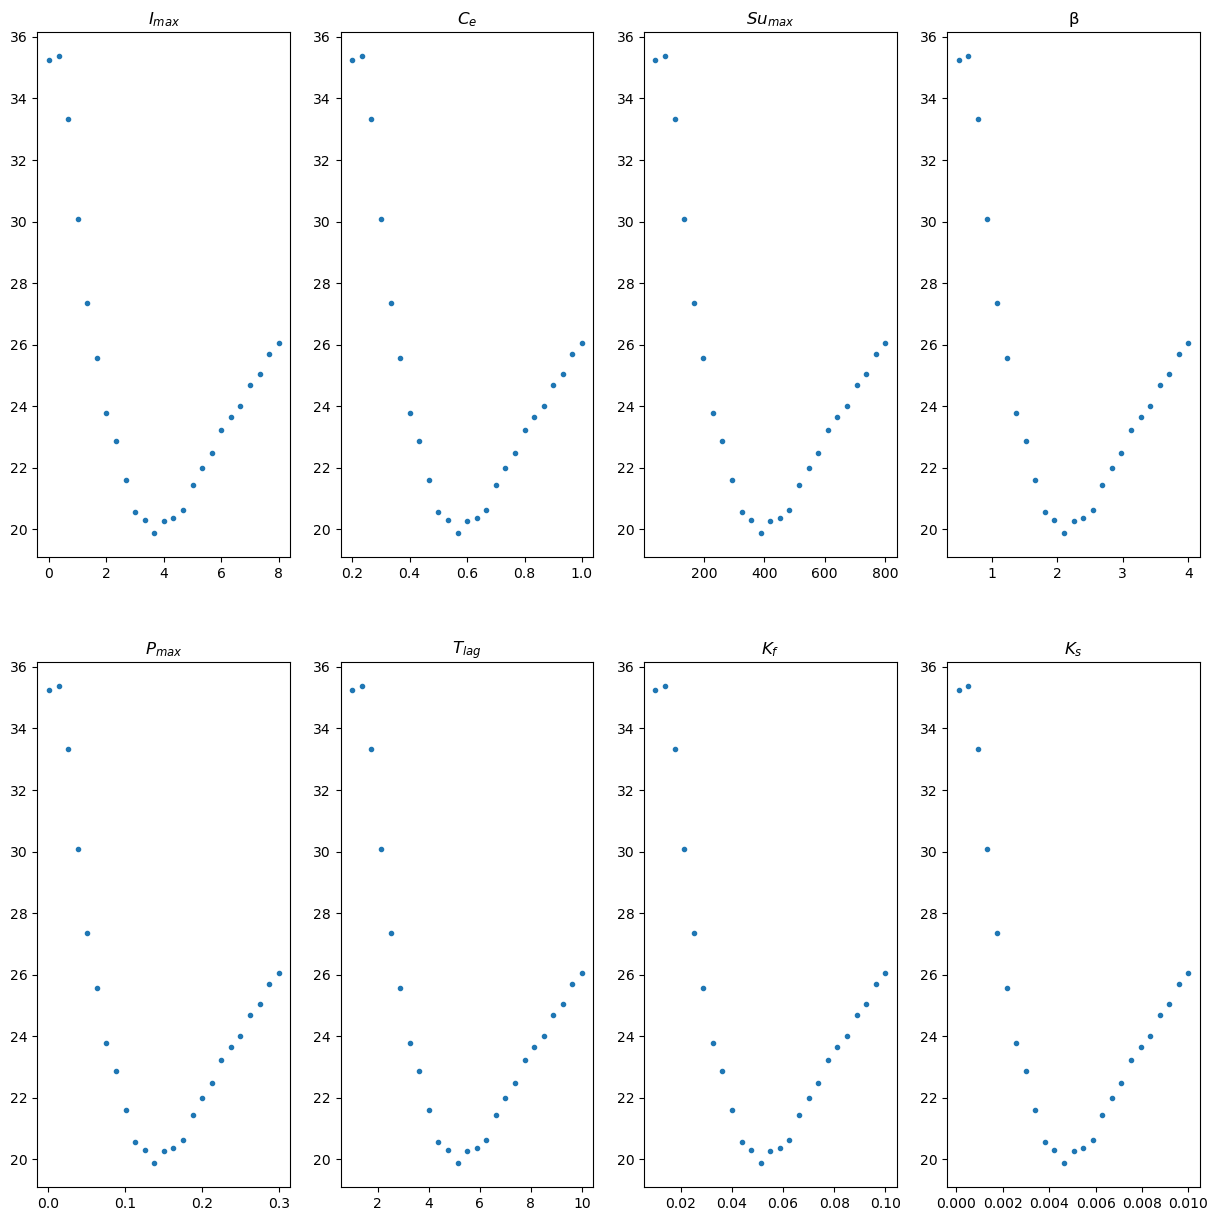

In [95]:
xFigNr = 2
yFigNr = 4

fig, axs = plt.subplots(xFigNr, yFigNr,figsize = (15,15))

for xFig in range(xFigNr):
    for yFig in range(yFigNr):
        paramCounter = xFig*yFigNr + yFig
        axs[xFig,yFig].plot(parameters[paramCounter,:],objectives,'.')
        axs[xFig,yFig].set_title(p_names[paramCounter])


In [96]:
# Let's also show the minimal values:
parameters_minimum_index = np.argmin(np.array(objectives))

parameters_minimum = parameters[:,parameters_minimum_index]

print(parameters_minimum)

[3.66666667e+00 5.66666667e-01 3.88333333e+02 2.10416667e+00
 1.38041667e-01 5.12500000e+00 5.12500000e-02 4.63750000e-03]

In [97]:
# Let's also show the maximum values:
parameters_maximum_index = np.argmax(np.array(objectives))

parameters_maximum = parameters[:,parameters_maximum_index]

print(parameters_maximum)

[3.33333333e-01 2.33333333e-01 7.16666667e+01 6.45833333e-01
 1.34583333e-02 1.37500000e+00 1.37500000e-02 5.12500000e-04]

# Exercise: Create your own calibration method!

### Calibration 
As mentioned above: the method of choosing parameters is bad and the objective function is also far from optimal in this notebook. In this exercise, you will again an ensemble, but now you are askes to use another method to create the parameters and use Nash and Sutcliffe coefficient as objective function. Calculate both the normal NSE and the log(NSE). Compare both and see (and understand) what the difference is between them?

The Nash and Sutcliffe coefficient is calculated using the formula:


$$
    N = 1 - \frac{\sum_{i=1}^{n}(Q_{o,i} - Q_{m,i})^2}{\sum_{i=1}^{n}(O_{o,i} - \bar{O}_{o})^2}
$$

Where Q is discharge, the subscripts o and m stand for observed and modeled respectively, i is the time step, and the overbar indicates an average.



Use the code cells below to create the calibration method. Calculate the NSE value for 5000 ensemble members. Re-use the structure of the code above and edit it to create a randomly chosen parameter set and calculate the objectives NSE and Log(NSE). What is the optimal parameter set for your region?

**NOTE** you will need to remake the ensemble array, because we finalized it earlier. Otherwise you get an `_bmi is missing` error message.


In [98]:
print("Cal period:", calibration_start_time, calibration_end_time)
print("Val period:", validation_start_time, validation_end_time)


Cal period: 2010-01-01T00:00:00Z 2010-12-31T00:00:00Z

Val period: 2011-01-01 2011-03-29

In [99]:
ParMinn = np.array([
    0.5,     # Imax
    0.1,     # Ce
    200.0,   # Sumax
    0.5,     # beta
    0.05,    # Pmax
    1.0,     # Tlag
    0.05,    # Kf
    0.001    # Ks
])

ParMaxn = np.array([
    5.0,     # Imax
    0.7,     # Ce
    800.0,   # Sumax
    3.0,     # beta
    1.0,     # Pmax
    5.0,     # Tlag
    0.5,     # Kf
    0.05     # Ks
])


Sin = np.array([0, 100, 0, 5])

# Create a random parameter set based on the ParMinn and ParMaxn array. 
# Do not use np.linspace as above. 
def calibrationObjective_NSE(modelOutput, observation, start_calibration, end_calibration):
    hydro_data = pd.concat(
        [modelOutput.reindex(observation.index, method="ffill"), observation],
        axis=1
    )

    # Make calibration times tz-naive to match hydro_data.index
    start = pd.to_datetime(start_calibration).tz_localize(None)
    end = pd.to_datetime(end_calibration).tz_localize(None)

    hydro_data = hydro_data[
        (hydro_data.index >= start) & (hydro_data.index <= end)
    ]

    model_q = hydro_data["model output"]
    obs_q = hydro_data["Q"]

    # Fix NaNs in obs
    nan_index = np.where(np.isnan(obs_q))[0]
    if len(nan_index) > 0:
        obs_q.iloc[nan_index] = (
            obs_q.iloc[nan_index - 1].values + obs_q.iloc[nan_index + 1].values
        ) / 2

    # NSE
    nse =  1- np.sum((model_q - obs_q) ** 2) / np.sum((obs_q - obs_q.mean()) ** 2)

    # log(NSE)
    eps = 1e-6
    log_model = np.log(model_q + eps)
    log_obs = np.log(obs_q + eps)
    log_nse = 1 - np.sum((log_model - log_obs) ** 2) / np.sum(
        (log_obs - log_obs.mean()) ** 2
    )

    # Distance from perfect (1,1)
    De = np.sqrt((1 - nse) ** 2 + (1 - log_nse) ** 2)

    return nse, log_nse, De




In [100]:

# HBV CALIBRATION 


n_ensemble = 75

all_params = []
all_nse = []
all_lognse = []
all_De = []

for i in range(n_ensemble):

    #  Sample random parameter set
    par = ParMinn + (ParMaxn - ParMinn) * np.random.rand(8)

    #  Run HBV with this parameter set
    model = HBV(forcing=ERA5_forcing)
    config_file, _ = model.setup(
        parameters=",".join(str(p) for p in par),
        initial_storage=",".join(str(s) for s in Sin),
    )
    model.initialize(config_file)

    # Run model for full experiment period
    Q_m = []
    time = []
    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime.date()))

    df = pd.DataFrame({"model output": Q_m}, index=time)

    #  Compute objective function for calibration period
    nse, lognse, De = calibrationObjective_NSE(
        df["model output"],
        grdc_obs,
        calibration_start_time,
        calibration_end_time
    )

    #  Store results
    all_params.append(par)
    all_nse.append(nse)
    all_lognse.append(lognse)
    all_De.append(De)

# Convert lists to arrays
all_params = np.array(all_params)
all_nse = np.array(all_nse)
all_lognse = np.array(all_lognse)
all_De = np.array(all_De)

# -----------------------------
# Build a results DataFrame
# -----------------------------
results = pd.DataFrame({
    "Imax": all_params[:,0],
    "Ce": all_params[:,1],
    "Sumax": all_params[:,2],
    "beta": all_params[:,3],
    "Pmax": all_params[:,4],
    "Tlag": all_params[:,5],
    "Kf": all_params[:,6],
    "Ks": all_params[:,7],
    "NSE": all_nse,
    "logNSE": all_lognse,
    "De": all_De
})

# -----------------------------
# Extract best parameter set
# -----------------------------
best_index = results["De"].idxmin()
par_best = all_params[np.argmax(all_nse)]

# par_best = results.loc[best_index, ["Imax","Ce","Sumax","beta","Pmax","Tlag","Kf","Ks"]].values

print("Best parameter set:", par_best)
print("Best NSE:", results.loc[best_index, "NSE"])
print("Best logNSE:", results.loc[best_index, "logNSE"])
print("Best De:", results.loc[best_index, "De"])

# -----------------------------
# Extract min/max values for later analysis
# -----------------------------
print("\nNSE range:", results["NSE"].min(), "to", results["NSE"].max())
print("logNSE range:", results["logNSE"].min(), "to", results["logNSE"].max())
print("De range:", results["De"].min(), "to", results["De"].max())


Best parameter set: [3.63012412e+00 5.49325750e-01 6.35235419e+02 5.06303518e-01
 6.59349249e-01 2.93275839e+00 3.50480201e-01 4.05325818e-02]

Best NSE: -0.6908584874424153

Best logNSE: -19.220325469391177

Best De: 20.29089856346105

NSE range: -0.7757581832123148 to -0.6908584874424153

logNSE range: -67.61975912667764 to -19.220325469391177

De range: 20.29089856346105 to 68.64272782956652

In [101]:

 #minimum De
best_index_min = np.argmin(all_De)
par_best_min = all_params[best_index_min]
# maximum NSE
best_index_max = np.argmax(all_nse)
par_best_max = all_params[best_index_max]

#  maximum logNSE
best_index_maxlog = np.argmax(all_lognse)
par_best_maxlog = all_params[best_index_maxlog]

print("Best by De:", par_best_min)
print("Best by NSE:", par_best_max)
print("Best by logNSE:", par_best_maxlog)



Best by De: [3.63012412e+00 5.49325750e-01 6.35235419e+02 5.06303518e-01
 6.59349249e-01 2.93275839e+00 3.50480201e-01 4.05325818e-02]

Best by NSE: [3.63012412e+00 5.49325750e-01 6.35235419e+02 5.06303518e-01
 6.59349249e-01 2.93275839e+00 3.50480201e-01 4.05325818e-02]

Best by logNSE: [3.63012412e+00 5.49325750e-01 6.35235419e+02 5.06303518e-01
 6.59349249e-01 2.93275839e+00 3.50480201e-01 4.05325818e-02]

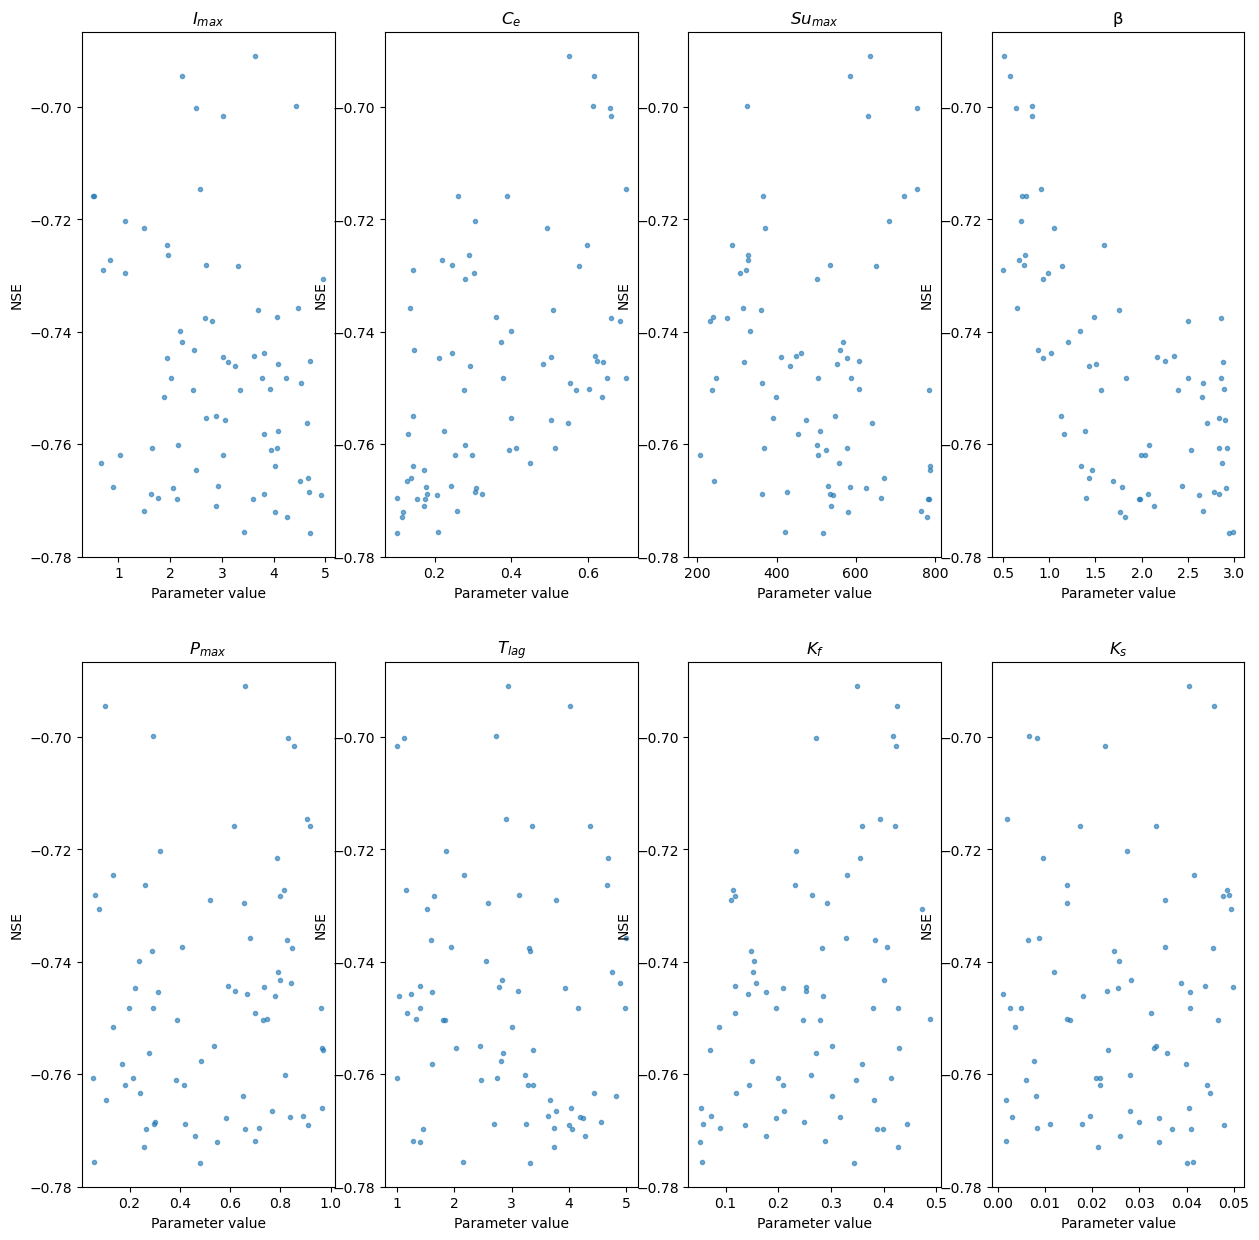

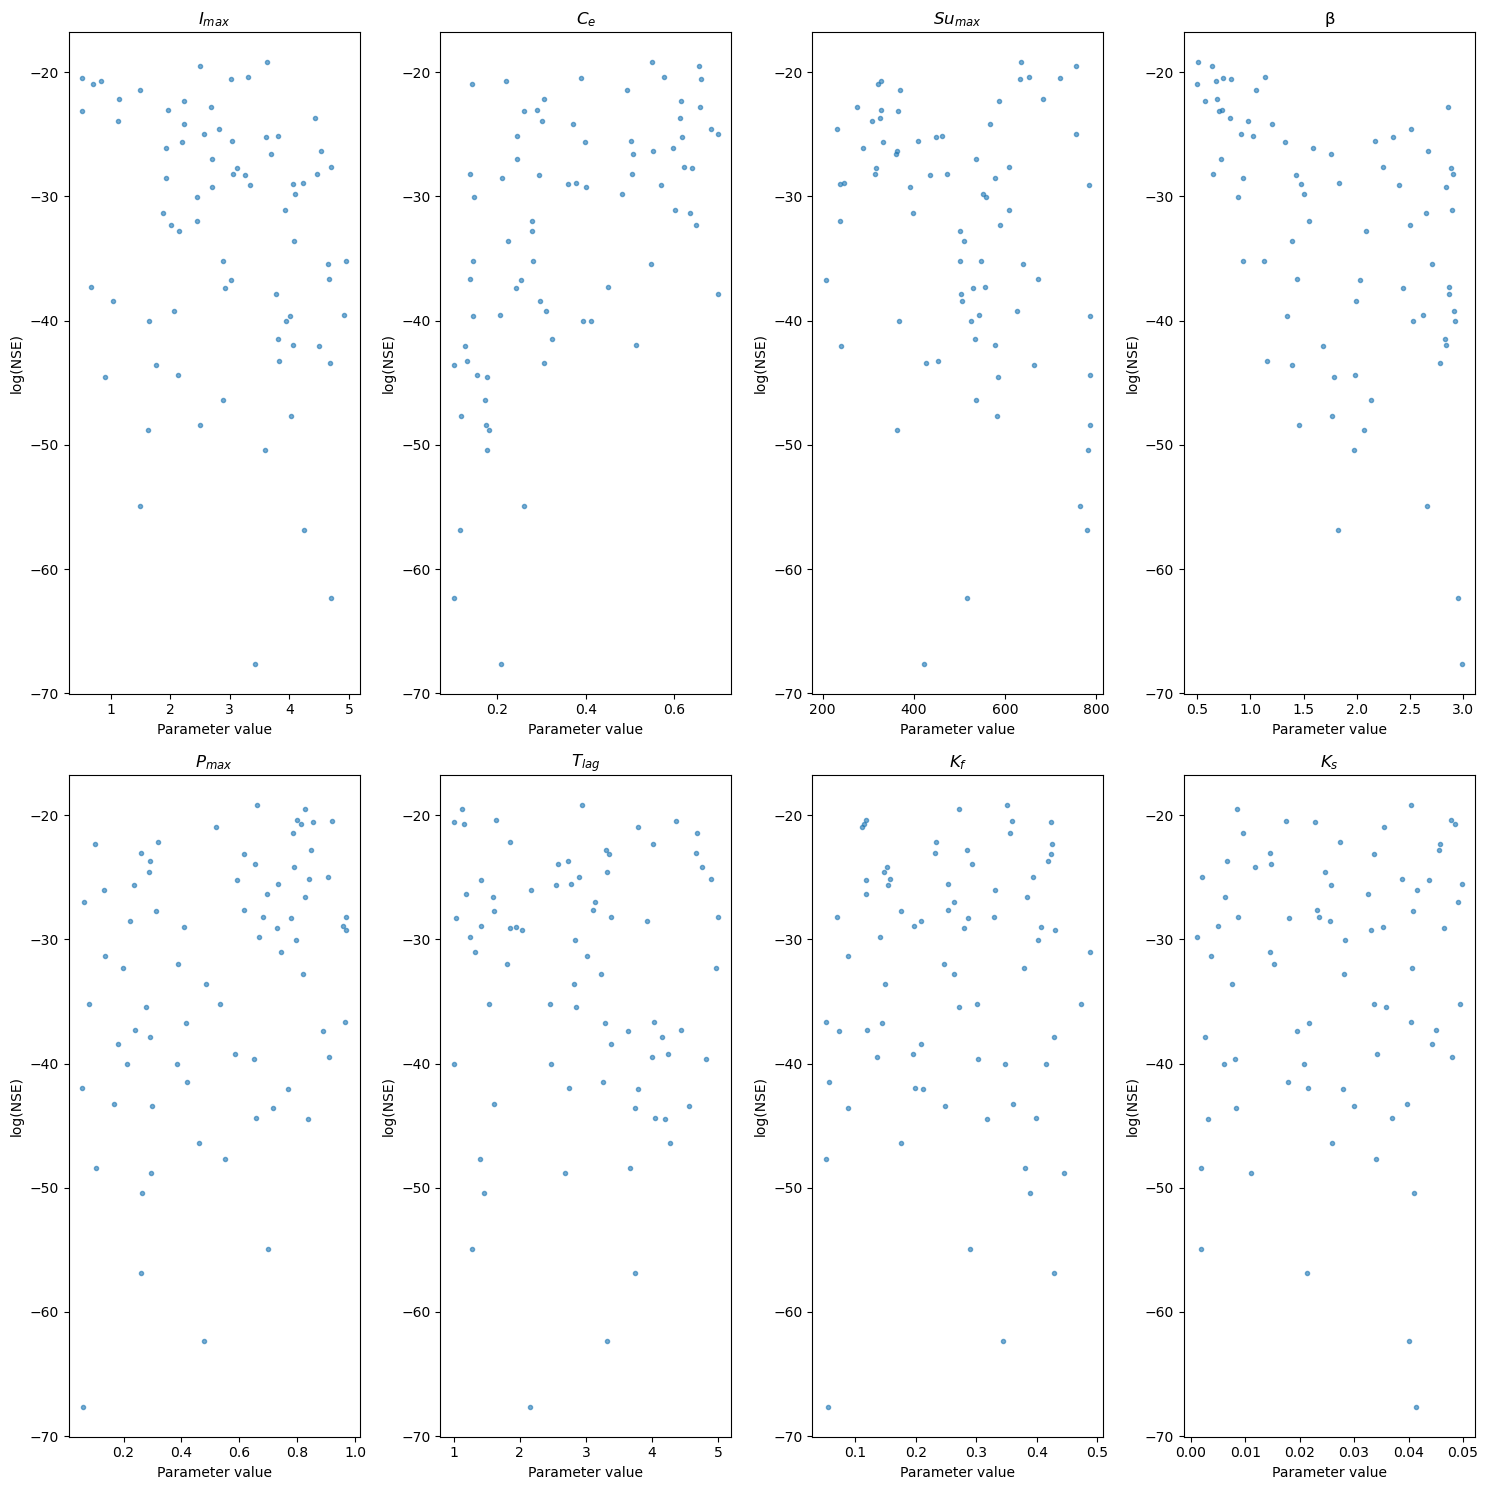

In [102]:
xFigNr = 2
yFigNr = 4

fig_nse, axs_nse = plt.subplots(xFigNr, yFigNr, figsize=(15, 15))
fig_nselog, axs_nselog = plt.subplots(xFigNr, yFigNr, figsize=(15, 15))

# Use your new arrays
nse_values = all_nse
log_nse_values = all_lognse
parameters = all_params   # shape (500, 8)

for xFig in range(xFigNr):
    for yFig in range(yFigNr):
        paramCounter = xFig * yFigNr + yFig

        # Safety check: don't exceed number of parameters
        if paramCounter >= parameters.shape[1]:
            axs_nse[xFig, yFig].axis("off")
            axs_nselog[xFig, yFig].axis("off")
            continue

        # Extract the parameter column
        param_values = parameters[:, paramCounter]

        # NSE plot
        axs_nse[xFig, yFig].plot(param_values, nse_values, ".", alpha=0.6)
        axs_nse[xFig, yFig].set_title(p_names[paramCounter])
        axs_nse[xFig, yFig].set_xlabel("Parameter value")
        axs_nse[xFig, yFig].set_ylabel("NSE")

        # logNSE plot
        axs_nselog[xFig, yFig].plot(param_values, log_nse_values, ".", alpha=0.6)
        axs_nselog[xFig, yFig].set_title(p_names[paramCounter])
        axs_nselog[xFig, yFig].set_xlabel("Parameter value")
        axs_nselog[xFig, yFig].set_ylabel("log(NSE)")

plt.tight_layout()
plt.show()


### Validation
If you look carefully in the first few cells of this notebook, you can see that a different calibration and validation period is added. You can extend this notebook and calculate the values of the objective function for the validation period: how does the model perform for the periods where it was not calibrated for?

Calibration NSE: -0.6908584874424153

Calibration logNSE: -19.220325469391177

Calibration De: 20.29089856346105

Validation NSE: -1.5162239728685907

Validation logNSE: -36.05408420577585

Validation De: 37.13942028909938

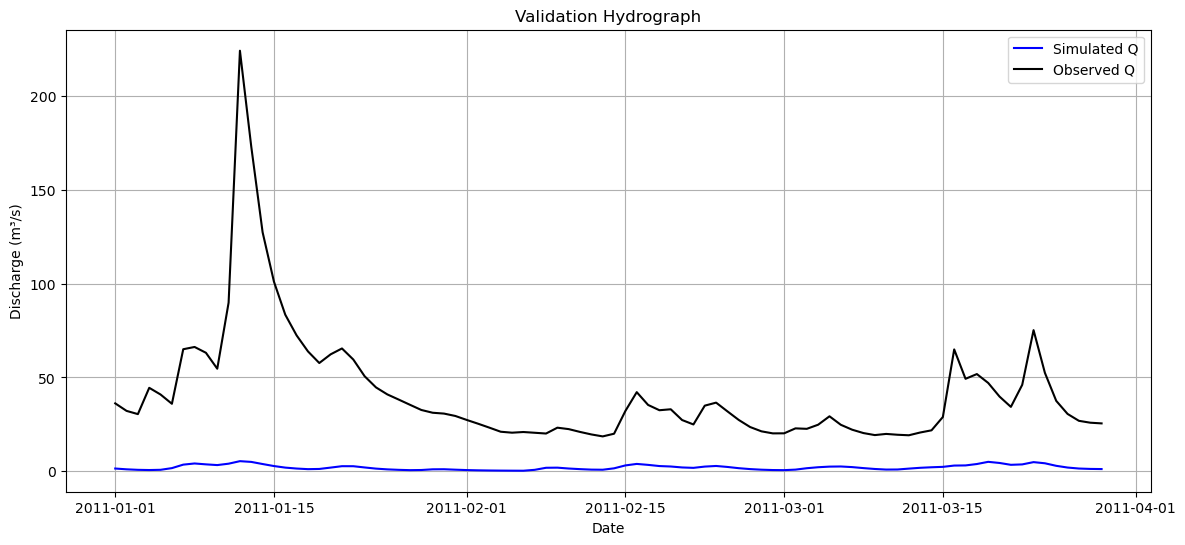

In [103]:
# -----------------------------------------
# RUN HBV WITH BEST PARAMETERS (VALIDATION)
# -----------------------------------------

# 1. Run HBV using the best parameter set
model_val = HBV(forcing=ERA5_forcing)

config_file, _ = model_val.setup(
    parameters=",".join(str(p) for p in par_best),
    initial_storage=",".join(str(s) for s in Sin),
)

model_val.initialize(config_file)

# 2. Run model for full experiment period
Q_val = []
time_val = []

while model_val.time < model_val.end_time:
    model_val.update()
    Q_val.append(model_val.get_value("Q")[0])
    time_val.append(pd.Timestamp(model_val.time_as_datetime.date()))

df_val = pd.DataFrame({"model output": Q_val}, index=time_val)

# -----------------------------------------
# CALIBRATION METRICS (sanity check)
# -----------------------------------------
nse_cal, lognse_cal, De_cal = calibrationObjective_NSE(
    df_val["model output"],
    grdc_obs,
    calibration_start_time,
    calibration_end_time
)

print("Calibration NSE:", nse_cal)
print("Calibration logNSE:", lognse_cal)
print("Calibration De:", De_cal)

# -----------------------------------------
# VALIDATION METRICS
# -----------------------------------------
nse_val, lognse_val, De_val = calibrationObjective_NSE(
    df_val["model output"],
    grdc_obs,
    validation_start_time,
    validation_end_time
)

print("\nValidation NSE:", nse_val)
print("Validation logNSE:", lognse_val)
print("Validation De:", De_val)

# -----------------------------------------
# VALIDATION HYDROGRAPH PLOT
# -----------------------------------------
plt.figure(figsize=(14,6))

# Extract validation period
start_val = pd.to_datetime(validation_start_time).tz_localize(None)
end_val = pd.to_datetime(validation_end_time).tz_localize(None)

df_plot = df_val.loc[start_val:end_val]
obs_plot = grdc_obs.loc[start_val:end_val]

plt.plot(df_plot.index, df_plot["model output"], label="Simulated Q", color="blue")
plt.plot(obs_plot.index, obs_plot["Q"], label="Observed Q", color="black")

plt.title("Validation Hydrograph")
plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.grid(True)
plt.show()


In [104]:

# import xarray as xr
# shape_area_manning = 6642*1e6 #m2

# # ---------------------------------------------------------
# # 1. Convert observed discharge to xarray (already in mm/day)
# # ---------------------------------------------------------
# Obs_data = grdc_obs["Q"].to_xarray().rename("Observed data")


# # ---------------------------------------------------------
# # 2. Run HBV again with par_best (full period)
# # ---------------------------------------------------------
# model_plot = HBV(forcing=ERA5_forcing)

# config_file, _ = model_plot.setup(
#     parameters=",".join(str(p) for p in par_best),
#     initial_storage=",".join(str(s) for s in Sin),
# )

# model_plot.initialize(config_file)

# Q_plot = []
# time_plot = []

# while model_plot.time < model_plot.end_time:
#     model_plot.update()
#     Q_plot.append(model_plot.get_value("Q")[0])
#     time_plot.append(pd.Timestamp(model_plot.time_as_datetime.date()))

# # ---------------------------------------------------------
# # 3. Create DataFrame for simulated discharge (m³/s)
# # ---------------------------------------------------------
# df_plot_sim = pd.DataFrame({"Simulated discharge": Q_plot}, index=time_plot)

# # ---------------------------------------------------------
# # 4. Convert simulated discharge to mm/day (Option A)
# # ---------------------------------------------------------
# df_plot_sim["Simulated discharge"] = (
#     df_plot_sim["Simulated discharge"] * 86400 / shape_area_manning * 1000
# )


# # ---------------------------------------------------------
# # 5. Convert simulated discharge to xarray
# # ---------------------------------------------------------
# sim_data = df_plot_sim["Simulated discharge"].to_xarray().rename("Simulated data")
# sim_data = sim_data.rename({"index": "time"})


# # ---------------------------------------------------------
# # 6. Convert validation times to tz‑naive
# # ---------------------------------------------------------
# val_start = pd.to_datetime(validation_start_time).tz_localize(None)
# val_end   = pd.to_datetime(validation_end_time).tz_localize(None)


# # ---------------------------------------------------------
# # 7. Slice validation period
# # ---------------------------------------------------------
# sim_val = sim_data.sel(time=slice(val_start, val_end))
# obs_val = Obs_data.sel(time=slice(val_start, val_end))


# # ---------------------------------------------------------
# # 8. Merge into a single DataFrame
# # ---------------------------------------------------------
# discharge = xr.merge([sim_val, obs_val]).to_dataframe()
# hydro_data = discharge[["Simulated data", "Observed data"]].dropna()



In [83]:
# parameters_maximum_index = np.argmax(np.array(nse_values))
# print(nse_values[parameters_maximum_index])
# print(parameters_maximum_index)
# parameters_maximum = parameters[:,parameters_maximum_index]
# print(parameters_maximum)

In [57]:
# parameters_maximum_index = np.argmax(np.array(log_nse_values))
# print(log_nse_values[parameters_maximum_index])
# print(parameters_maximum_index)
# parameters_maximum = parameters[:,parameters_maximum_index]
# print(parameters_maximum)

0.2140253794959902

9

[3.00000e+00 5.00000e-01 3.25000e+02 1.81250e+00 1.13125e-01 4.37500e+00
 4.37500e-02 3.81250e-03]

In [58]:
# De = [i[2] for i in objectives]
# # print(De)
# parameters_index_min = np.argmin(np.array(De))
# print(parameters_index_min)
# print(De[parameters_index_min])
# parameters_maximum = parameters[:,parameters_index_min]
# print(parameters_maximum)

9

0.7868745455608

[3.00000e+00 5.00000e-01 3.25000e+02 1.81250e+00 1.13125e-01 4.37500e+00
 4.37500e-02 3.81250e-03]

In [59]:
# Observed Discharge 
Obs = pd.read_csv("./Data/5202080_Q_Day.Cmd.txt",delimiter=";",skiprows=36,header=0,encoding="cp1252",index_col=0,parse_dates=True)

Obs.index.name = "Day"
Obs = Obs.rename(columns={" Value": "Q"})  # note the space in original file
shape_area_manning = 6642*1e6 #m2
# Convert m³/s → mm/day over basin
Obs["Q"] = Obs["Q"] * 86400 / shape_area_manning * 1000

# Remove unrealistic values
Obs.loc[Obs["Q"] > 4000, "Q"] = np.nan

# Restrict to experiment period
Obs_1 = Obs.loc["2001-01-01":"2003-12-31"]

# Convert to xarray with time coordinate
Obs_data = Obs_1["Q"].to_xarray().rename({"Day": "time"})
Obs_data = Obs_data.rename("Observed data")


In [60]:
import xarray as xr
# Q modeled
par = np.array([2.30217914e+00, 5.82136251e-01, 7.80053510e+02, 1.01243743e+00, 2.89364414e-01, 1.06375915e+00, 3.25619436e-02, 4.08444666e-03])
s_0 = np.array([0,  100,  0,  5])

model = HBV(forcing=ERA5_forcing)

config_file, _ = model.setup(
                            parameters=','.join([str(p) for p in par]),
                            initial_storage=','.join([str(s) for s in s_0]),
                               )

model.initialize(config_file)

Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    discharge_this_timestep = model.get_value("Q")
    Q_m.append(discharge_this_timestep[0])
    time.append(pd.Timestamp(model.time_as_datetime.date())) 
    
df = pd.DataFrame(data=Q_m,columns=["Modeled discharge"], index=time)

df["Modeled discharge"] = df["Modeled discharge"] * shape_area_manning / (1000 * 86400)
sim_data = df["Modeled discharge"].to_xarray().rename({'index': 'date'}) 
sim_data = sim_data.rename({'date': 'time'})

# Convert validation times to tz-naive
val_start = pd.to_datetime(validation_start_time).tz_localize(None)
val_end   = pd.to_datetime(validation_end_time).tz_localize(None)

# Slice validation period
sim_val = sim_data.sel(time=slice(val_start, val_end))
obs_val = Obs_data.sel(time=slice(val_start, val_end))

sim_data

# Rename variables
sim_data = sim_data.rename("Simulated data")
Obs_data = Obs_data.rename("Observed data")

# Merge
discharge = xr.merge([sim_data, Obs_data]).to_dataframe()

# Select columns
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()


In [61]:
import xarray as xr
discharge = xr.merge([sim_data, Obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()
hydro_data

,Simulated data,Observed data
time,,


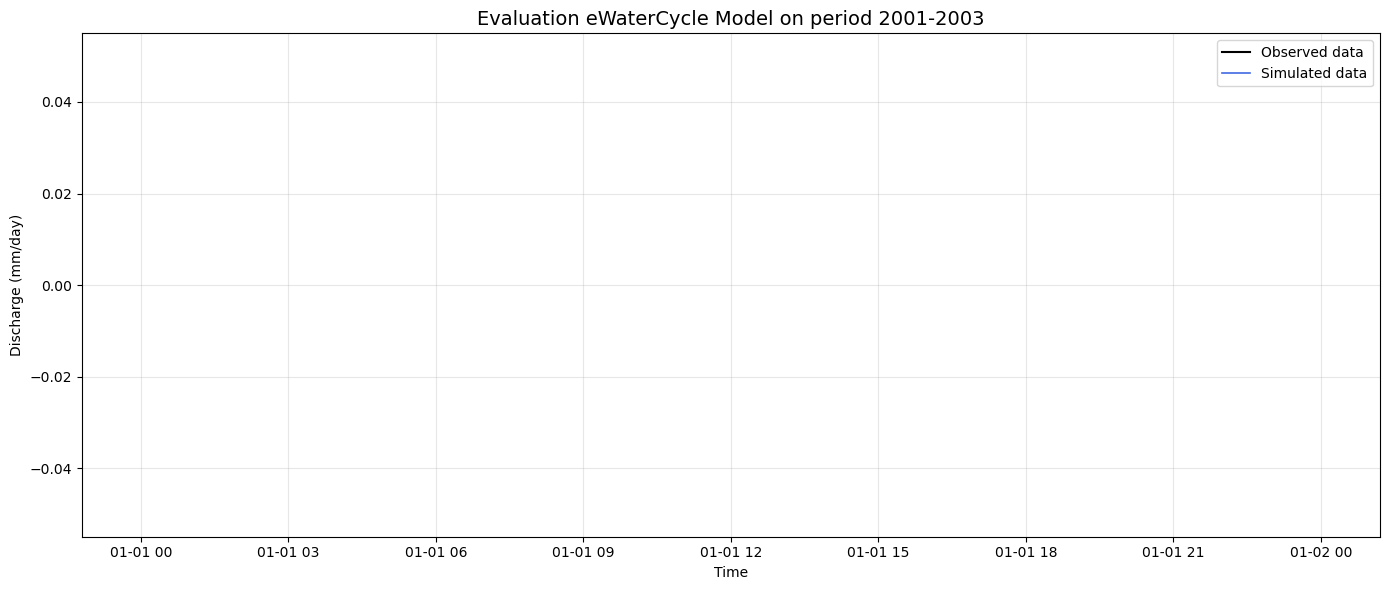

In [62]:
import os
os.makedirs("./Evaluation Calibration", exist_ok=True)

plt.figure(figsize=(14, 6))

plt.plot(hydro_data.index, hydro_data["Observed data"], label="Observed data", color="black", linewidth=1.5)
plt.plot(hydro_data.index, hydro_data["Simulated data"], label="Simulated data", color="royalblue", linewidth=1.2)

plt.title("Evaluation eWaterCycle Model on period 2001-2003", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Discharge (mm/day)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./Evaluation Calibration/experiment_hydrograph_eval_19961999.png", dpi=300)
plt.show()



In [63]:
model.finalize()

In [64]:

# Restrict to experiment period
Obs_1 = Obs.loc["2009-01-01":"2010-12-31"]

# Convert to xarray with time coordinate
Obs_data = Obs_1["Q"].to_xarray().rename({"Day": "time"})
Obs_data = Obs_data.rename("Observed data")

In [65]:
discharge = xr.merge([sim_data, Obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()
hydro_data

,Simulated data,Observed data
time,,
2010-01-02,8.554034,1.351727
2010-01-03,17.846555,1.022972
2010-01-04,20.935197,2.277281
2010-01-05,20.697560,1.932852
2010-01-06,20.163300,1.561327
...,...,...
2010-12-27,130.120281,0.718231
2010-12-28,134.545845,0.987356
2010-12-29,132.783874,1.150660


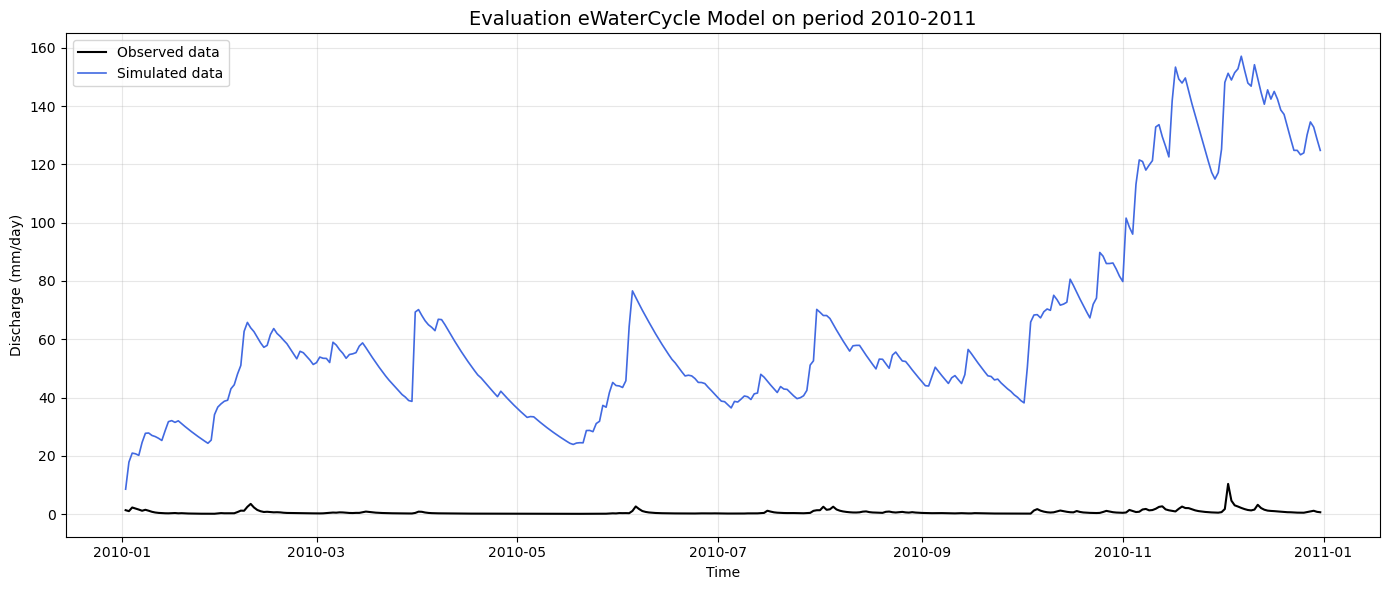

In [66]:
import os
os.makedirs("./Evaluation Calibration", exist_ok=True)

plt.figure(figsize=(14, 6))

plt.plot(hydro_data.index, hydro_data["Observed data"], label="Observed data", color="black", linewidth=1.5)
plt.plot(hydro_data.index, hydro_data["Simulated data"], label="Simulated data", color="royalblue", linewidth=1.2)

plt.title("Evaluation eWaterCycle Model on period 2010-2011", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Discharge (mm/day)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./Evaluation Calibration/experiment_hydrograph_eval_19961999.png", dpi=300)
plt.show()

In [67]:

# Restrict to experiment period
Obs_1 = Obs.loc["2003-01-01":"2006-12-31"]

# Convert to xarray with time coordinate
Obs_data = Obs_1["Q"].to_xarray().rename({"Day": "time"})
Obs_data = Obs_data.rename("Observed data")

In [68]:
discharge = xr.merge([sim_data, Obs_data]).to_dataframe()
hydro_data = discharge[["Simulated data", "Observed data"]].dropna()
hydro_data

,Simulated data,Observed data
time,,


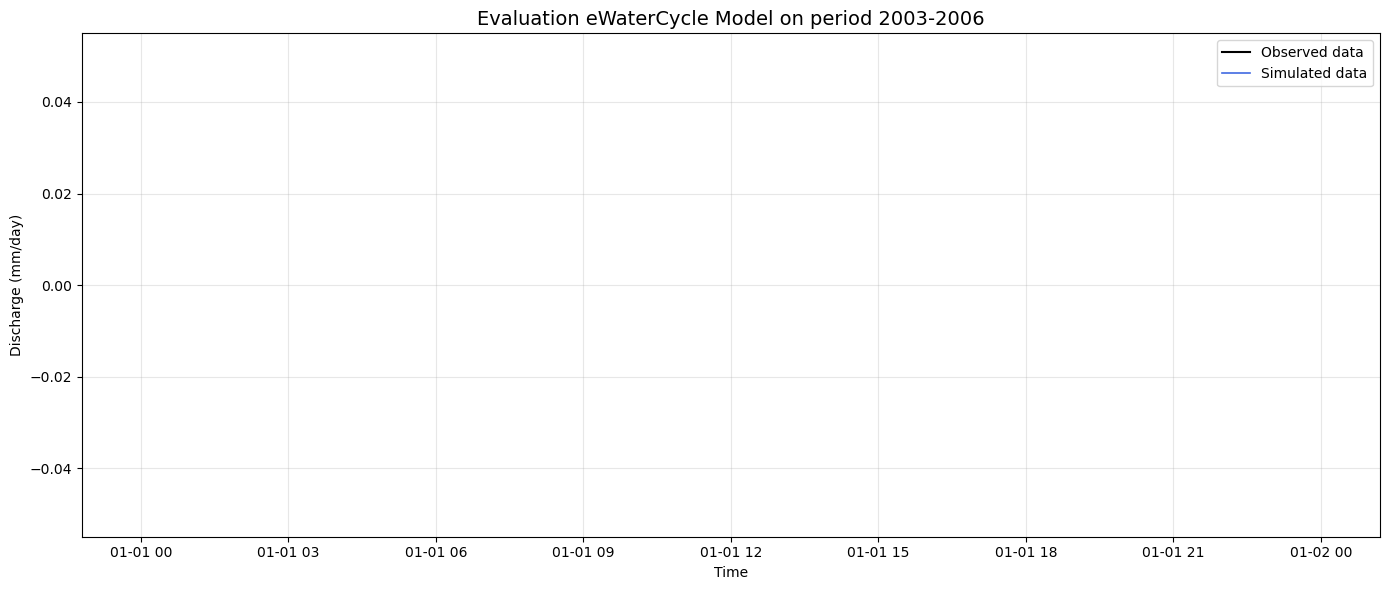

In [69]:
import os
os.makedirs("./Evaluation Calibration", exist_ok=True)

plt.figure(figsize=(14, 6))

plt.plot(hydro_data.index, hydro_data["Observed data"], label="Observed data", color="black", linewidth=1.5)
plt.plot(hydro_data.index, hydro_data["Simulated data"], label="Simulated data", color="royalblue", linewidth=1.2)

plt.title("Evaluation eWaterCycle Model on period 2003-2006", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Discharge (mm/day)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./Evaluation Calibration/experiment_hydrograph_eval_19961999.png", dpi=300)
plt.show()

## Note on files

Each model now has its own directory in the configFiles directory. If everything goes well, these are deleted with the ```finalize()``` command above. If however due to an error, they persist, you may not be able to create a new ensemble. In that case, uncomment the line in the cell below and run that. But be careful! this will remove all the files in the configFiles directory.

In [35]:
#!rm -r configFiles/*